Base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Visualizando DataFrame
df = pd.read_csv("winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


In [19]:
# Verificando os tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [20]:
# Verificando dados faltantes
df.isnull().values.any()

np.False_

In [21]:
# Verificando novamente
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [22]:
# Começando tratamento e realizando tradução das colunas para o português
df = df.rename(columns={'fixed acidity': 'acidez_fixa',
                        'volatile acidity': 'acidez_volatil',
                        'citric acid': 'acido_citrico',
                        'residual sugar': 'acucar_residual',
                        'chlorides': 'cloretos',
                        'free sulfur dioxide': 'dioxido_enxofre_livre',
                        'total sulfur dioxide': 'dioxido_enxofre_total',
                        'density': 'densidade',
                        'pH': 'ph',
                        'sulphates': 'sulfatos',
                        'alcohol': 'alcool',
                        'quality': 'qualidade_vinho',
                        })

In [23]:
df.head()

,acidez_fixa,acidez_volatil,acido_citrico,acucar_residual,cloretos,dioxido_enxofre_livre,dioxido_enxofre_total,densidade,ph,sulfatos,alcool,qualidade_vinho
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [24]:
# Verificando Outliers
df.describe()

,acidez_fixa,acidez_volatil,acido_citrico,acucar_residual,cloretos,dioxido_enxofre_livre,dioxido_enxofre_total,densidade,ph,sulfatos,alcool,qualidade_vinho
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


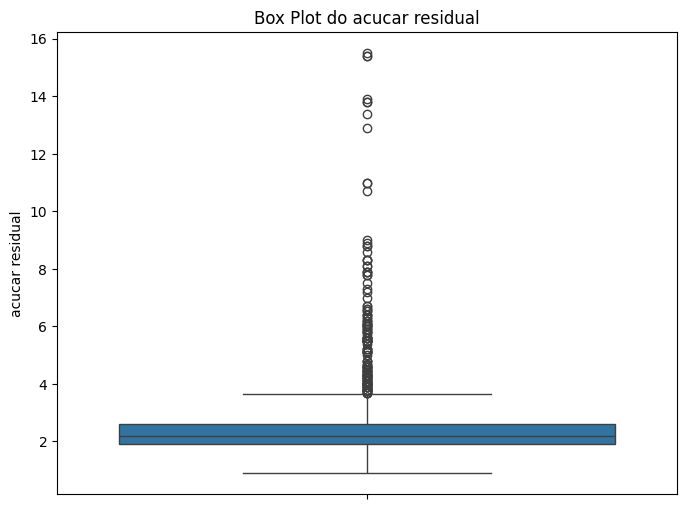

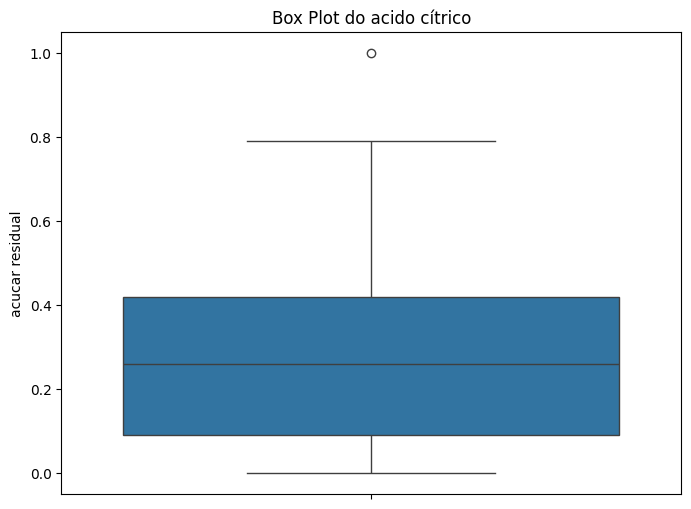

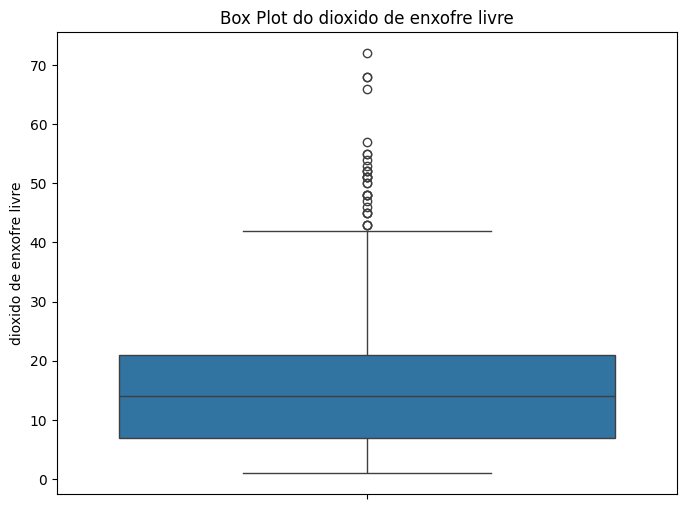

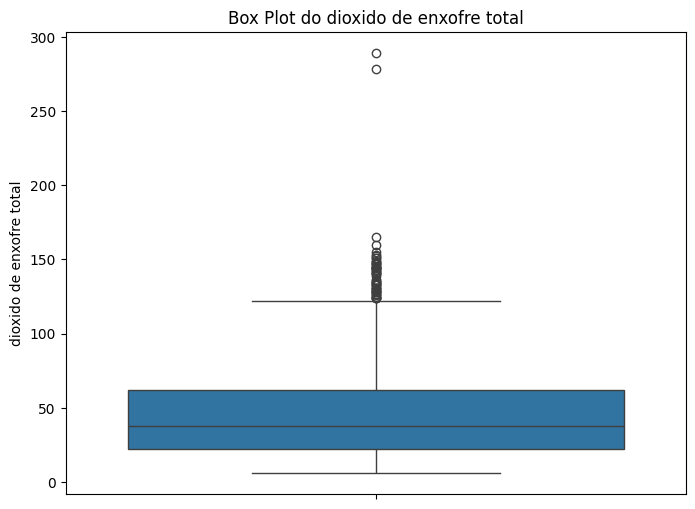

In [25]:
# Box plot para 'acucar residual'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['acucar_residual'])
plt.title('Box Plot do acucar residual')
plt.ylabel('acucar residual')
plt.show()

# Box plot para 'acido cítrico'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['acido_citrico'])
plt.title('Box Plot do acido cítrico')
plt.ylabel('acucar residual')
plt.show()

# Box plot para 'dioxido de enxofre livre'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['dioxido_enxofre_livre'])
plt.title('Box Plot do dioxido de enxofre livre')
plt.ylabel('dioxido de enxofre livre')
plt.show()

# Box plot para 'dioxido de enxofre total'
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['dioxido_enxofre_total'])
plt.title('Box Plot do dioxido de enxofre total')
plt.ylabel('dioxido de enxofre total')
plt.show()

Foi identificado Outliers nas variaveis: Acido Citrico, Açucar Residual, Dioxido de Enxofre Livre e Dioxido de Enxofre Total, porem decidimos manter as variaveis, já que o modelo que vamos utilizar roda bem com presenças de Outliers.

In [26]:
df['qualidade_vinho'].value_counts(normalize=True) * 100

,proportion
qualidade_vinho,
5,42.589118
6,39.899937
7,12.445278
4,3.314572
8,1.125704
3,0.625391


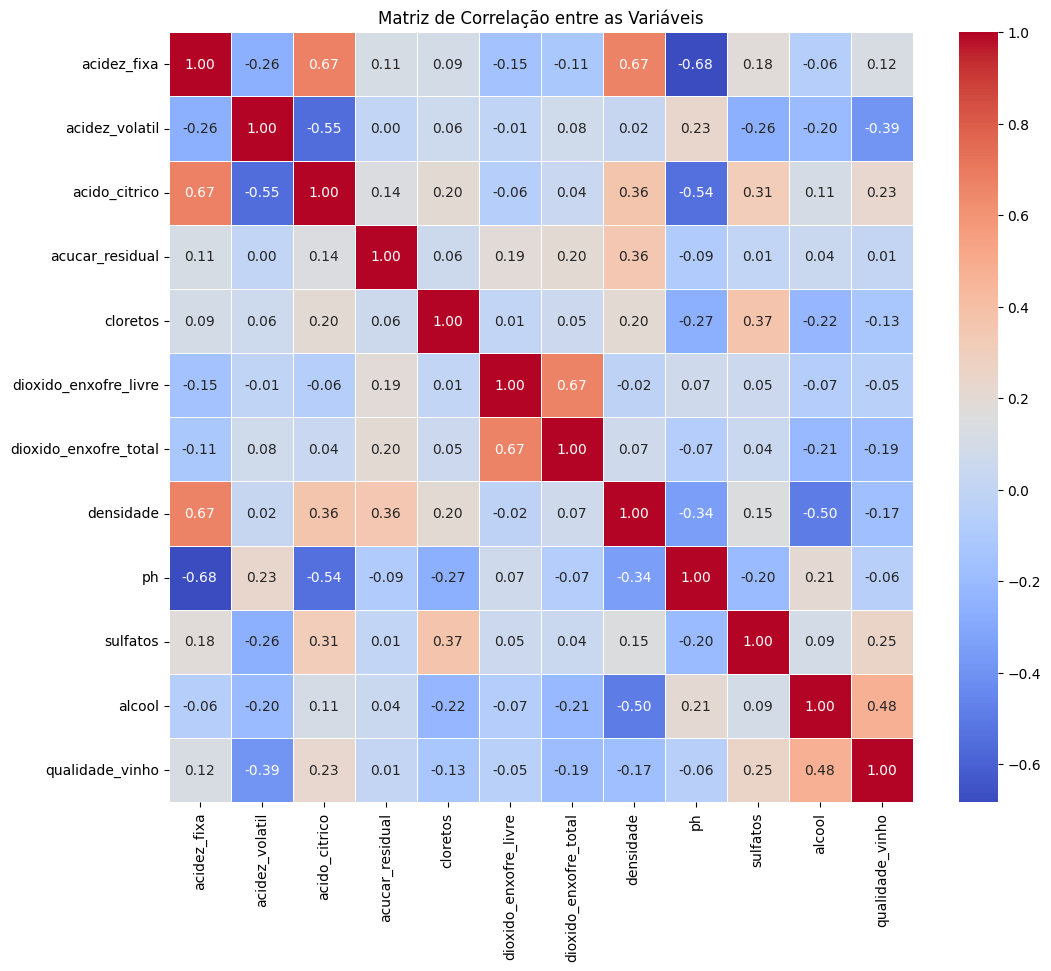

In [27]:
import numpy as np

# Calcular a matriz de correlação
correlation_matrix = df.corr()

# Plotar a matriz de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação entre as Variáveis')
plt.show()


In [28]:
# Insights sobre as correlações mais fortes
print("\nInsights sobre a Matriz de Correlação:\n")

# Pegar as correlações da variável target 'qualidade_vinho' com as outras variáveis
qualidade_corr = correlation_matrix['qualidade_vinho'].sort_values(ascending=False)
print("Correlação com 'qualidade do vinho':\n", qualidade_corr)

# Outras correlações fortes (excluindo a correlação de uma variável com ela mesma)
strong_correlations = correlation_matrix[abs(correlation_matrix) > 0.3]

# Remove a diagonal (correlação da variável com ela mesma)
np.fill_diagonal(strong_correlations.values, np.nan)

print("\nOutras correlações fortes (magnitude > 0.3):\n")
# Para evitar duplicatas e ter uma leitura mais limpa
for i in range(len(strong_correlations.columns)):
    for j in range(i):
        if abs(strong_correlations.iloc[i, j]) > 0.3:
            print(f"  {strong_correlations.columns[i]} e {strong_correlations.columns[j]}: {strong_correlations.iloc[i, j]:.2f}")


Insights sobre a Matriz de Correlação:

Correlação com 'qualidade do vinho':
 qualidade_vinho          1.000000
alcool                   0.476166
sulfatos                 0.251397
acido_citrico            0.226373
acidez_fixa              0.124052
acucar_residual          0.013732
dioxido_enxofre_livre   -0.050656
ph                      -0.057731
cloretos                -0.128907
densidade               -0.174919
dioxido_enxofre_total   -0.185100
acidez_volatil          -0.390558
Name: qualidade_vinho, dtype: float64

Outras correlações fortes (magnitude > 0.3):

  acido_citrico e acidez_fixa: 0.67
  acido_citrico e acidez_volatil: -0.55
  dioxido_enxofre_total e dioxido_enxofre_livre: 0.67
  densidade e acidez_fixa: 0.67
  densidade e acido_citrico: 0.36
  densidade e acucar_residual: 0.36
  ph e acidez_fixa: -0.68
  ph e acido_citrico: -0.54
  ph e densidade: -0.34
  sulfatos e acido_citrico: 0.31
  sulfatos e cloretos: 0.37
  alcool e densidade: -0.50
  qualidade_vinho e acidez_vo

Variaveis que tem a maior correlação com a Target são: 'alcool', 'acidez_volatil', 'sulfatos', 'acido_cítrico'.



In [29]:
# Variáveis selecionadas com maior correlação com a 'qualidade_vinho'
selected_features = ['alcool', 'acidez_volatil', 'sulfatos', 'acido_citrico']

# Criando um novo DataFrame apenas com as variáveis selecionadas e a target
df_correlated = df[selected_features + ['qualidade_vinho']]

print("Novo DataFrame com variáveis correlacionadas:")
display(df_correlated.head())

Novo DataFrame com variáveis correlacionadas:


,alcool,acidez_volatil,sulfatos,acido_citrico,qualidade_vinho
0,9.4,0.70,0.56,0.00,5
1,9.8,0.88,0.68,0.00,5
2,9.8,0.76,0.65,0.04,5
3,9.8,0.28,0.58,0.56,6
4,9.4,0.70,0.56,0.00,5


In [30]:
# salvando DataFrame
df_correlated.to_csv('df_correlated.csv', index=False)

In [31]:
# Separando em X (variáveis de entrada) e Y (variável de saída)
X = df.drop('qualidade_vinho', axis=1)  # X contém todas as colunas exceto 'qualidade_vinho'
Y = df['qualidade_vinho']  # Y contém apenas a coluna 'qualidade_vinho'

In [32]:
# Separar em base de treino e teste (usando 80% para treino e 20% para teste)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [33]:
# Iniciando o modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)

In [34]:
# Treinando o modelo
rf_model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [35]:
# Fazendo previsões no conjunto de teste
Y_pred = rf_model.predict(X_test)

In [36]:
# Avaliando o modelo
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.66
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320

Matriz de Confusão:
 [[ 0  0  1  0  0  0]
 [ 0  0  7  3  0  0]
 [ 0  0 98 31  1  0]
 [ 0  1 31 91  8  1]
 [ 0  0  0 19 22  1]
 [ 0  0  0  1  4  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Insights sobre o Modelo Random Forest:**

**Acurácia Geral:** A acurácia do modelo é de 0.66 (66%). Isso significa que 66% das previsões do modelo estavam corretas no conjunto de teste. Para um problema de classificação multiclasse, essa é uma acurácia razoável, mas há espaço para melhorias, especialmente considerando a distribuição das classes.



**Relatório de Classificação (Precision, Recall, F1-Score):**

Classes 5 e 6: O modelo performou melhor nas classes 5 e 6, que são as classes mais frequentes. Para a classe 5, temos uma precisão de 0.72, recall de 0.75 e F1-score de 0.73. Para a classe 6, os valores são 0.63, 0.69 e 0.66, respectivamente. Isso é esperado, pois o modelo teve mais exemplos para aprender sobre essas classes.

Classe 7: A classe 7 teve uma performance aceitável, com F1-score de 0.57 (Precision: 0.63, Recall: 0.52). Embora menor que as classes 5 e 6, ainda demonstra alguma capacidade de previsão.

Classes 3, 4 e 8: O modelo teve uma performance muito ruim para as classes 3, 4 e 8, apresentando Precision, Recall e F1-score de 0.00. Isso indica que o modelo não conseguiu prever corretamente nenhuma instância dessas classes. Olhando para a matriz de confusão, podemos ver que estas classes foram quase totalmente ignoradas ou mal classificadas.

**Matriz de Confusão:**

A matriz de confusão reforça o que o relatório de classificação mostrou. Por exemplo:

Para a classe 3 (1 amostra no teste), o modelo não previu nenhuma corretamente (predição 0, recall 0).

Para a classe 4 (10 amostras no teste), o modelo não previu nenhuma corretamente.

Para a classe 8 (5 amostras no teste), o modelo não previu nenhuma corretamente.

A maioria das previsões para as classes minoritárias (3, 4, 7, 8) foi 'desviada' para as classes majoritárias (5 e 6), indicando uma tendência do modelo a prever as classes mais comuns.



**Podemos dizer que o modelo teve uma dificuldade evidente em prever as classes minoritárias (3, 4 e 8), e isso tem uma relação direta e muito forte com o balanceamento dos dados.**

In [37]:
# Verificando o balanceamento
# Contar o número de exemplos de cada classe em y_train
train_balance = Y_train.value_counts()
print("Balanceamento em Y_train:")
print(train_balance)

# Contar o número de exemplos de cada classe em y_test
test_balance = Y_test.value_counts()
print("\nBalanceamento em Y_test:")
print(test_balance)

Balanceamento em Y_train:
qualidade_vinho
5    551
6    506
7    157
4     43
8     13
3      9
Name: count, dtype: int64

Balanceamento em Y_test:
qualidade_vinho
6    132
5    130
7     42
4     10
8      5
3      1
Name: count, dtype: int64


Foi observado uma enorme diferença no número de amostras entre as classes. Por exemplo, a classe '5' e '6' juntas representam mais de 80% do dataset. As classes '3', '4' e '8' são muito raras.
O modelo de Random Forest (ou qualquer outro modelo de aprendizado de máquina) naturalmente tem dificuldades em aprender padrões para classes que aparecem muito poucas vezes nos dados de treino. Ele tende a focar nas classes majoritárias para maximizar a acurácia geral, o que leva a uma performance pobre nas classes com poucos exemplos (baixa representatividade).

Para melhorar a capacidade do modelo de prever essas classes minoritárias, técnicas de tratamento de desbalanceamento de classes serão essenciais, como oversampling (ex: SMOTE) ou undersampling, ou ainda o uso de algoritmos que considerem o custo do erro de classificação de forma diferente para cada classe.

In [38]:
# Melhorando Hiperparametros
# Definir o espaço de busca dos hiperparâmetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

In [39]:
# Configurando o Randomized Search
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
                                   n_iter=100, cv=5, n_jobs=-1, verbose=2, random_state=42, scoring='accuracy')

In [40]:
# Executando o Randomized Search
random_search.fit(X_train, Y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200]},
                   random_state=42, scoring='accuracy', verbose=2)

In [41]:
# Obtendo os melhores hiperparâmetros através do método randomico
best_params = random_search.best_params_
print(f"Melhores Hiperparâmetros: {best_params}")

Melhores Hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


In [42]:
# Treinando o modelo com os melhores hiperparâmetros encontrados acima
best_rf_model = random_search.best_estimator_
best_rf_model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

In [43]:
Y_pred = best_rf_model.predict(X_test)

In [44]:
# Avaliando o novo modelo
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f"Acurácia: {accuracy:.2f}")
print("Relatório de Classificação:\n", report)
print("Matriz de Confusão:\n", conf_matrix)

Acurácia: 0.66
Relatório de Classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.74      0.72       130
           6       0.61      0.71      0.66       132
           7       0.68      0.50      0.58        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320

Matriz de Confusão:
 [[ 0  0  1  0  0  0]
 [ 0  0  6  4  0  0]
 [ 0  0 96 34  0  0]
 [ 0  0 32 94  6  0]
 [ 0  0  0 20 21  1]
 [ 0  0  0  1  4  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Conclusão da Otimização de Hiperparâmetros e Desafios Remanescentes

### Análise Comparativa do Modelo Original e Otimizado

Ao comparar os resultados do modelo Random Forest original com o modelo otimizado via Randomized Search, observamos o seguinte:

*   **Acurácia Geral:** Ambos os modelos apresentaram uma acurácia geral de 0.66 (66%). Isso sugere que, em termos de classificações corretas em todo o conjunto de dados, a otimização de hiperparâmetros não trouxe uma melhoria significativa na acurácia global.

*   **Relatório de Classificação:**
    *   **Classes 5 e 6 (Majoritárias):** O desempenho nessas classes permaneceu robusto e consistente. No modelo original, a classe 5 tinha F1-score de 0.73 e a classe 6 de 0.66. No modelo otimizado, a classe 5 teve F1-score de 0.72 e a classe 6 de 0.66. Pequenas variações podem ser observadas, mas sem mudanças drásticas.
    *   **Classe 7:** O F1-score para a classe 7 foi de 0.57 no modelo original e 0.58 no modelo otimizado, indicando uma ligeira melhora, mas ainda mantendo um desempenho moderado.
    *   **Classes 3, 4 e 8 (Minoritárias):** Infelizmente, para as classes com menor representatividade (3, 4 e 8), o cenário permaneceu inalterado. Ambos os modelos apresentaram Precision, Recall e F1-score de 0.00 para essas classes. Isso significa que, mesmo após a otimização de hiperparâmetros, o modelo ainda não conseguiu prever corretamente nenhuma amostra dessas classes.

*   **Matriz de Confusão:** As matrizes de confusão de ambos os modelos são muito semelhantes. Continuamos a observar que as amostras das classes 3, 4 e 8 são erroneamente classificadas como classes majoritárias (principalmente 5 e 6). Por exemplo, a classe 3 (1 amostra) foi classificada como 5, a classe 4 (10 amostras) foi classificada como 5 ou 6, e a classe 8 (5 amostras) foi classificada como 6 ou 7. Isso reforça a incapacidade do modelo de aprender e identificar essas classes minoritárias.

### Conclusão sobre a Otimização de Hiperparâmetros

Embora o Randomized Search tenha encontrado uma combinação de hiperparâmetros (`n_estimators`: 200, `min_samples_split`: 2, `min_samples_leaf`: 1, `max_features`: 'sqrt', `max_depth`: 20) que poderiam ser considerados ótimos para a acurácia geral, **não houve melhorias tangíveis no desempenho do modelo em relação às classes minoritárias (3, 4 e 8)**. A otimização se concentrou em refinar a capacidade do modelo dentro do contexto existente, que já era dominado pelas classes majoritárias.

### Persistência dos Desafios de Balanceamento de Classes

Sim, **os desafios relacionados ao balanceamento de classes persistem e são a principal causa da baixa performance nas classes minoritárias**. A distribuição desbalanceada das classes é evidente tanto no conjunto de treino quanto no de teste:

*   **Y_train:** Classe 5 (551), Classe 6 (506), Classe 7 (157), Classe 4 (43), Classe 8 (13), Classe 3 (9).
*   **Y_test:** Classe 6 (132), Classe 5 (130), Classe 7 (42), Classe 4 (10), Classe 8 (5), Classe 3 (1).

Com tão poucas amostras para as classes 3, 4 e 8, o modelo não consegue extrair padrões suficientes para fazer previsões precisas para elas. Ele tende a priorizar as classes mais frequentes, onde um erro de classificação é menos penalizador para a acurácia geral.

### Aspectos que ainda necessitam de atenção e Técnicas Futuras

Para construir um modelo mais robusto e capaz de prever todas as classes de qualidade de vinho, os seguintes aspectos e técnicas precisam ser considerados:

1.  **Tratamento do Desbalanceamento de Classes:** Esta é a prioridade máxima.
    *   **Oversampling:** Técnicas como SMOTE (Synthetic Minority Oversampling Technique) podem ser aplicadas para gerar amostras sintéticas das classes minoritárias, aumentando sua representatividade no conjunto de treino.
    *   **Undersampling:** Reduzir o número de amostras das classes majoritárias para equilibrar o conjunto de dados. No entanto, esta técnica pode levar à perda de informações valiosas.
    *   **Combinação de Oversampling e Undersampling:** Abordagens híbridas podem ser eficazes para balancear o dataset sem perda excessiva de dados ou criação excessiva de dados sintéticos.
    *   **Ajuste de Pesos de Classes:** Muitos algoritmos de classificação, incluindo o Random Forest, permitem atribuir pesos maiores às classes minoritárias durante o treinamento, penalizando mais os erros de classificação nessas classes.

2.  **Métricas de Avaliação Adequadas:** Para datasets desbalanceados, a acurácia não é uma métrica suficiente. Deve-se focar em:
    *   **F1-Score:** Especialmente o F1-score ponderado (weighted F1-score) ou F1-score por classe, que oferece um equilíbrio entre precisão e recall para cada classe.
    *   **Recall:** Essencial para garantir que o modelo identifique o maior número possível de instâncias das classes minoritárias.
    *   **Precision:** Para garantir que as previsões para as classes minoritárias sejam corretas.
    *   **Área sob a curva ROC (AUC-ROC) e AUC-PR (Precision-Recall):** Estas são métricas mais robustas para avaliar modelos em dados desbalanceados, especialmente AUC-PR para classes minoritárias.

3.  **Outras Abordagens de Modelagem:** Explorar outros modelos que lidam bem com desbalanceamento ou que podem ser facilmente adaptados:
    *   **Algoritmos sensíveis a custos:** Modelos que permitem definir diferentes custos para diferentes tipos de erros de classificação.
    *   **Ensembles Avançados:** Técnicas como EasyEnsemble ou BalanceCascade que combinam múltiplos classificadores treinados em subconjuntos balanceados dos dados.

Em resumo, a otimização de hiperparâmetros por si só não foi suficiente para resolver o problema fundamental do desbalanceamento de classes. A próxima etapa crucial seria implementar estratégias para tratar esse desbalanceamento, juntamente com uma avaliação mais aprofundada usando métricas apropriadas, para que o modelo possa prever com eficácia as qualidades de vinho menos comuns.